## Bussiness Case:-
* Bob has started his own mobile company. He wants to give a tough fight to big companies like
Apple, Samsung etc 
He does not know how to estimate the price of mobiles his company creates. In this competitive
mobile phone market, you cannot simply assume things. To solve this problem he collects sales data
of mobile phones of various companies.


*  Bob wants to find out some relation between features of a mobile phone(eg:- RAM, Internal Memory
etc) and its selling price. But he is not so good at Machine Learning. So he needs your help to solve
this problem.
In this problem you do not have to predict the actual price but a price range indicating how high the
price is.

## Domain Analysis

In [1]:
# import the total python libraries for this project
import numpy as np  # use for numerical function
import pandas as pd  # use for data cleaning and data analysis
import matplotlib.pyplot as plt  # use data visualization
import seaborn as sns  # use for data visualization
import warnings # use for warnings the ignore
warnings.filterwarnings("ignore") # call the warning

In [2]:
# load the data set
data = pd.read_csv("datasets_11167_15520_train.csv")
data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


####   Atribute Information:-
**battery_power** - Total energy a battery can store in one time measured in mAh\
**blue** - Has bluetooth or not\
**clock_speed** - speed at which microprocessor executes instructions\
**dual_sim** - Has dual sim support or not\
**fc** - Front Camera mega pixels\
**four_g** - Has 4G or not\
**int_memory** - Internal Memory in Gigabytes\
**m_dep** - Mobile Depth in cm\
**mobile_wt** - Weight of mobile phone\
**n_cores** - Number of cores of processor\
**pc** - Primary Camera mega pixels\
**px_height** - Pixel Resolution Height\
**px_width** - Pixel Resolution Width\
**ram** - Random Access Memory in Megabytes\
**sc_h** - Screen Height of mobile in cm\
**sc_w** - Screen Width of mobile in cm\
**talk_time** - longest time that a single battery charge will last when you are\
**three_g** - Has 3G or not\
**touch_screen**- Has touch screen or not\
**wifi** - Has wifi or not\
**price_range** - This is the target variable with value of 0(low cost), 1(medium cost), 2(high
cost) and 3(very high cost).\

In [3]:
data.head() # showning the top 5 data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
data.tail() # showing the last 5 data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,...,483,754,3919,19,4,2,1,1,1,3


In [5]:
data.describe() # use for continous column show information

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [7]:
data.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [8]:
data.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

## EDA:- Exploratory Data Analysis

**Exploratory Data Analysis (EDA):-**  EDA in machine learning is the process of analyzing and visualizing datasets to summarize their main characteristics, often using statistical graphics and visualization techniques.
* There is a Three types of EDA :
1. Univariant Analysis
2. Biavariant Analysis
3. Multivariant Analysis

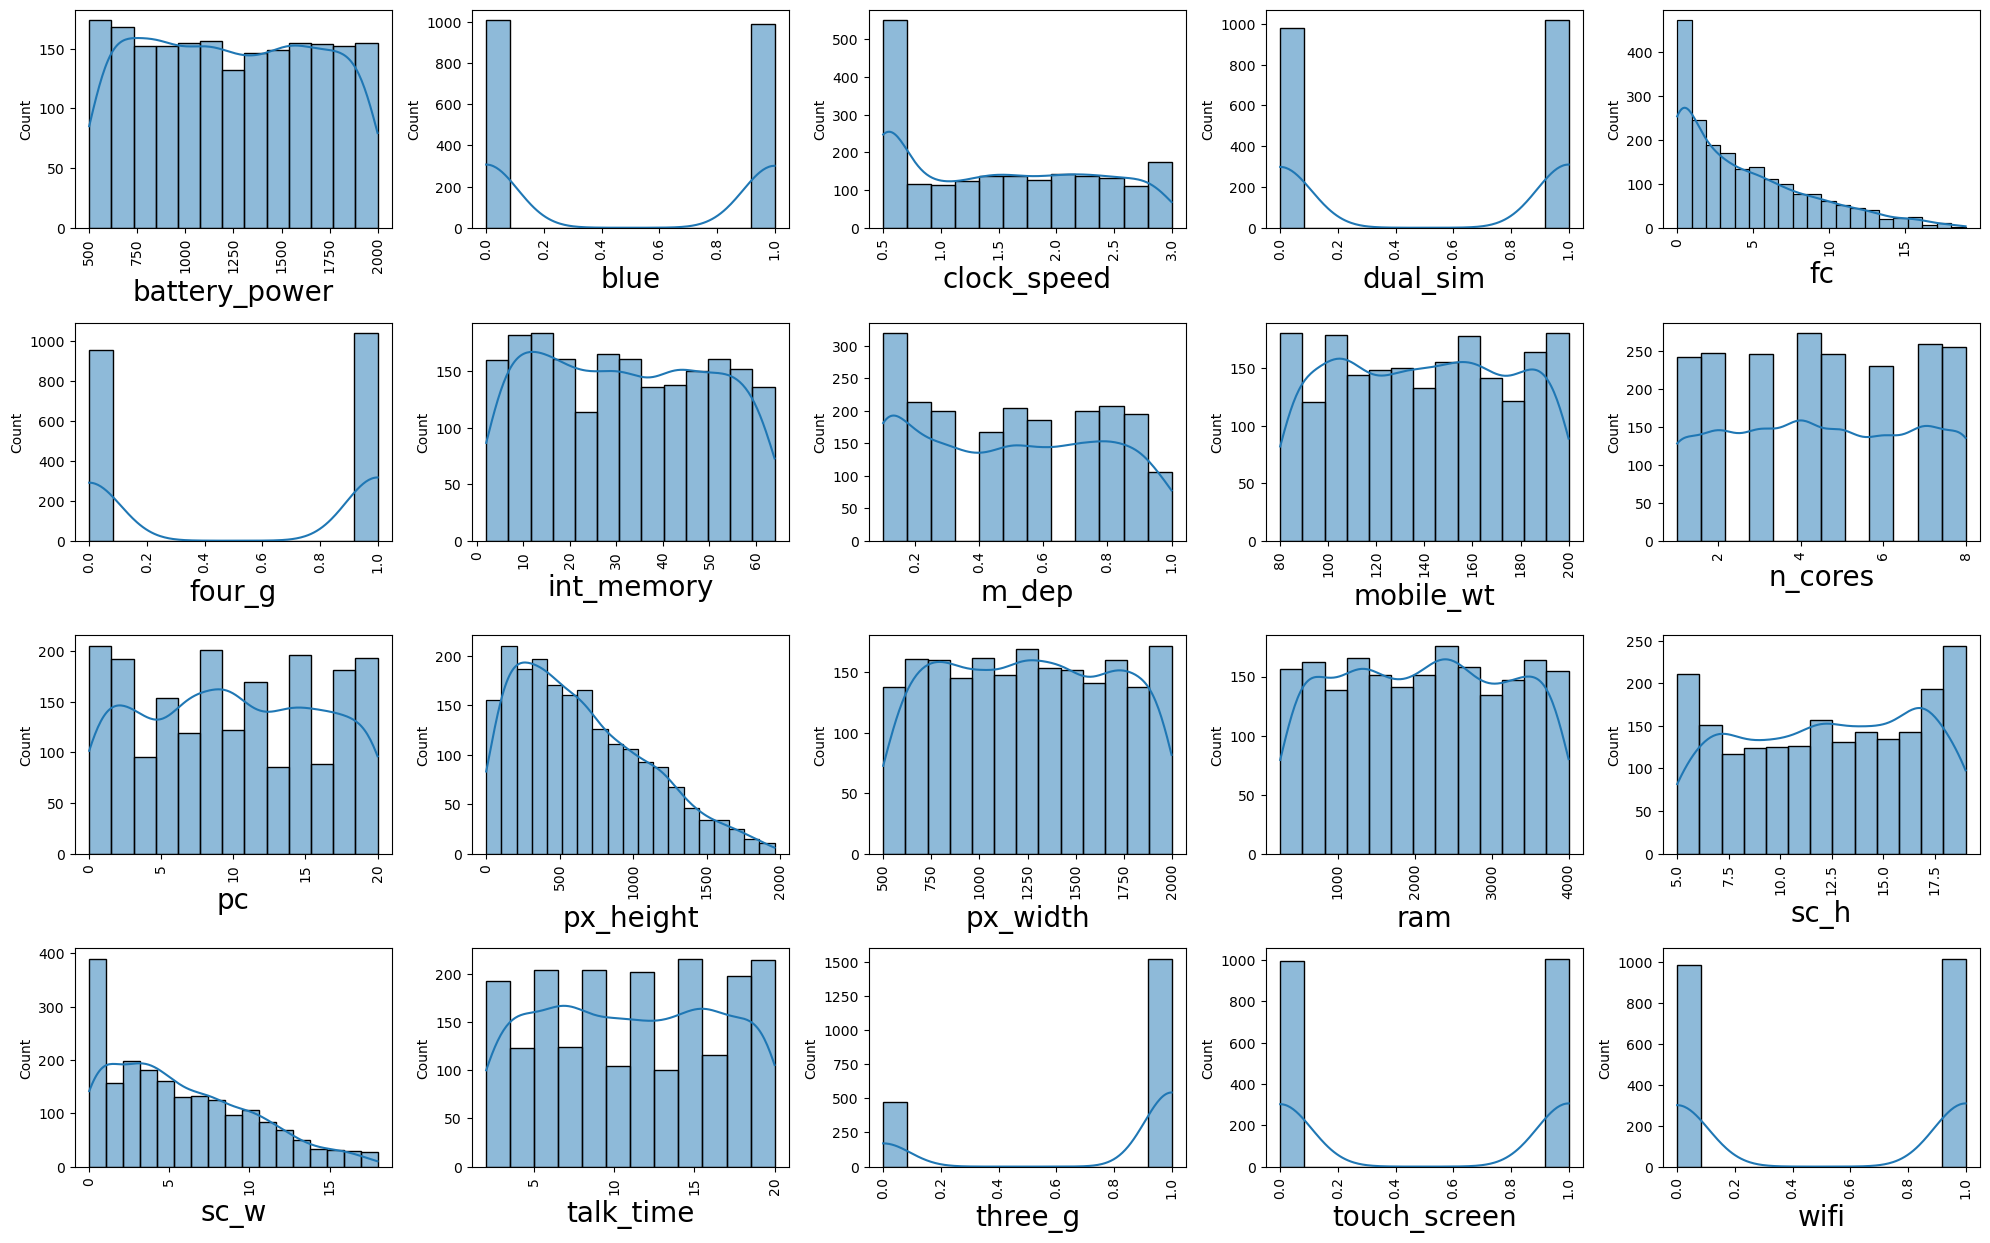

In [9]:
# Univeriant Analysis
plt.figure(figsize=(20,15)) # define the plot size
plt_num = 1
for column in data:
    if plt_num <= 20: # assighn the column value
        plt.subplot(5,5,plt_num) # row and column assighn
        sns.histplot(data[column],kde=True) # create the histogram plot
        plt.xlabel(column,fontsize = 20)
        plt.xticks(rotation = 90)# assighn the xlabel value
    plt_num += 1
plt.tight_layout() # use for data show function

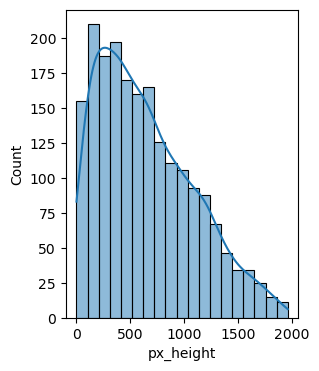

In [10]:
plt.figure(figsize=(3,4))
sns.histplot(x=data['px_height'], kde= True) # left screwed
plt.show()  # it looks like little bit left skewed

In [11]:
abc = np.sqrt(data['px_height'])

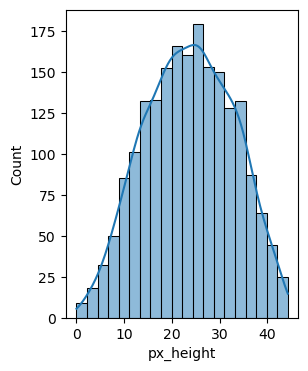

In [12]:
plt.figure(figsize=(3,4))
sns.histplot(abc, kde= True) 
plt.show()

In [13]:
data["px_height"] = abc

<Axes: xlabel='four_g', ylabel='n_cores'>

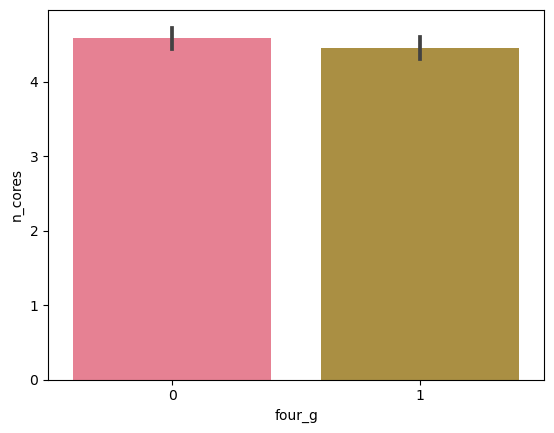

In [14]:
## Biaveriant Analysis
palette = sns.color_palette("husl") # use for bar color create
sns.barplot(x = data.four_g,y = data.n_cores, palette=palette) # create a barplot graph

In [15]:
# ## Biaveriant Analysis
# palette = sns.color_palette("husl") # use for bar color create
# sns.barplot(x = data.,y = data.cnt,palette=palette) # create a barplot graph

## Feature Engineering

**Feature Engineering:-** It is the process of using domain knowledge to select, modify, or create new features from raw data that can improve the performance of machine learning models. It involves transforming raw data into a format that is more suitable for modeling and can significantly impact model accuracy and effectiveness.

In [16]:
data1 = data[["battery_power","clock_speed","fc","int_memory","mobile_wt","m_dep","px_height","px_width","ram","talk_time","m_dep","n_cores","sc_h","sc_w"]]

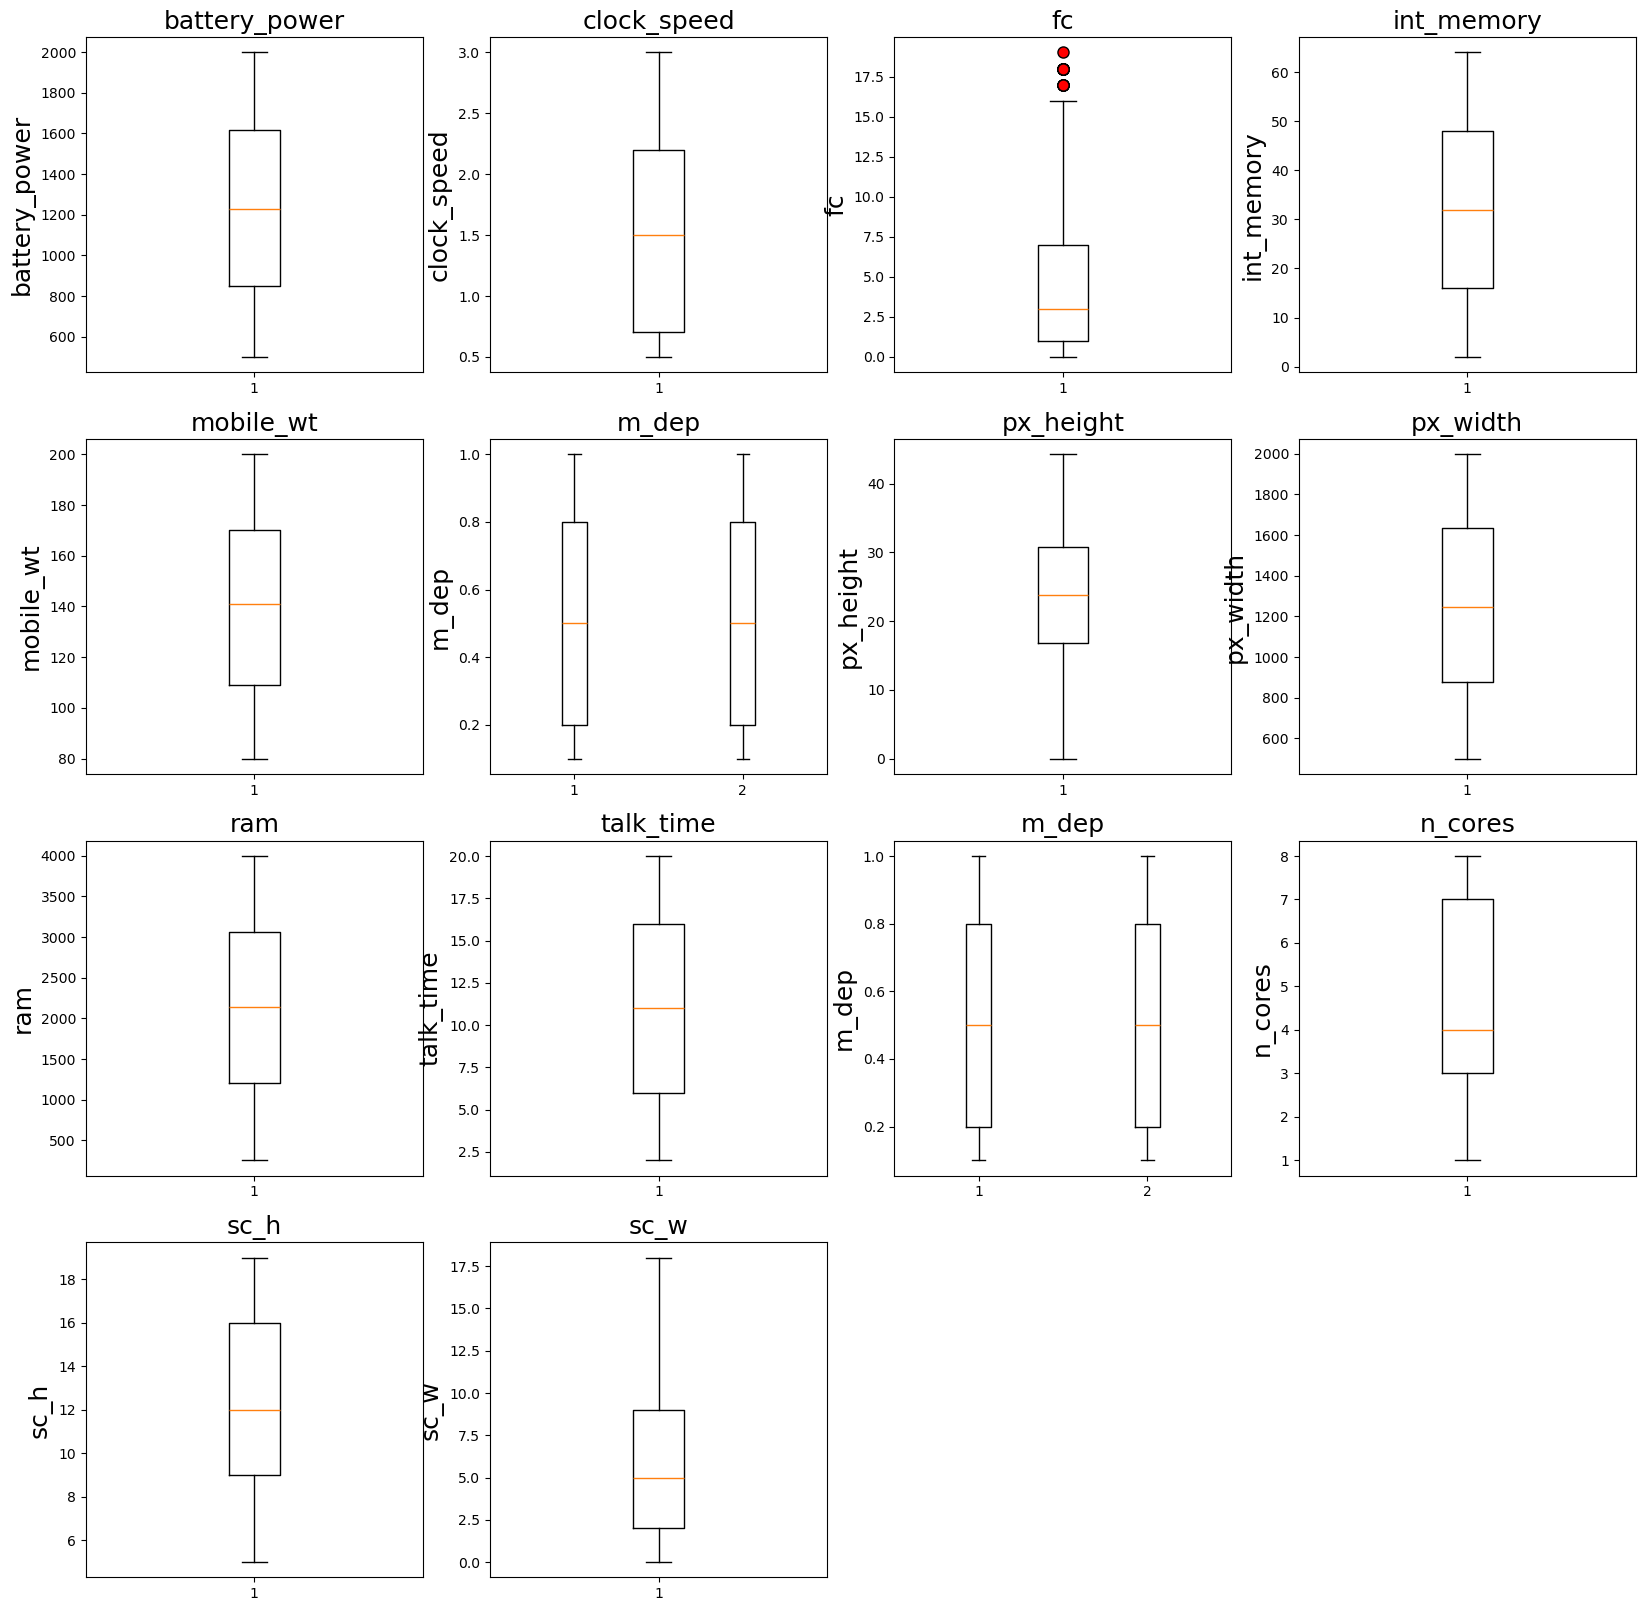

In [17]:
# here we are running a for loop for plot boxplot for all continous features.

plt.figure(figsize=(20,20))
plot_num = 1
flierprops = dict(marker='o', markerfacecolor='red', markersize=8)


for i in data1:
    if plot_num <= 14:
        plt.subplot(4,4,plot_num)
        plt.boxplot(data1[i],flierprops=flierprops)
        plot_num += 1
        plt.title(i, fontsize=18)
        plt.ylabel(i, fontsize=18)
        plt.title(i, fontsize=18)
        plt.show

<Axes: >

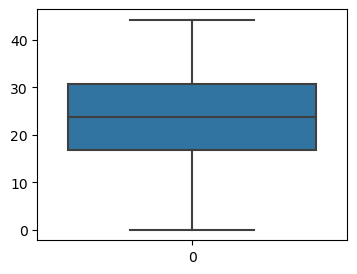

In [18]:
plt.figure(figsize=(4,3))
sns.boxplot(data.px_height)

In [19]:
data.loc[data["px_height"] > 1920, "px_height"]

Series([], Name: px_height, dtype: float64)

In [20]:
data.loc[data["px_height"] > 1920, "px_height"] = data.px_height.median() # here we are replacing null value with median manually

<Axes: >

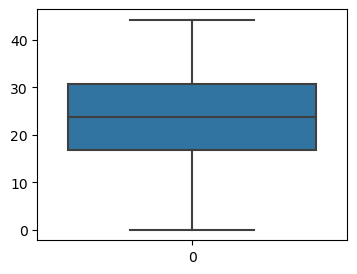

In [21]:
plt.figure(figsize=(4,3))
sns.boxplot(data.px_height)

In [22]:
data.loc[data["fc"] > 16.5, "fc"] = data.fc.median() # here we are replacing null value with median manually

<Axes: >

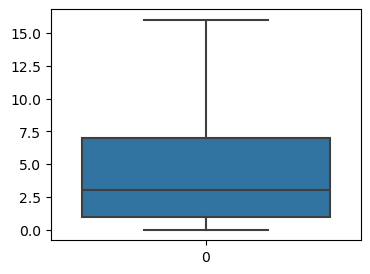

In [23]:
plt.figure(figsize=(4,3))
sns.boxplot(data.fc)

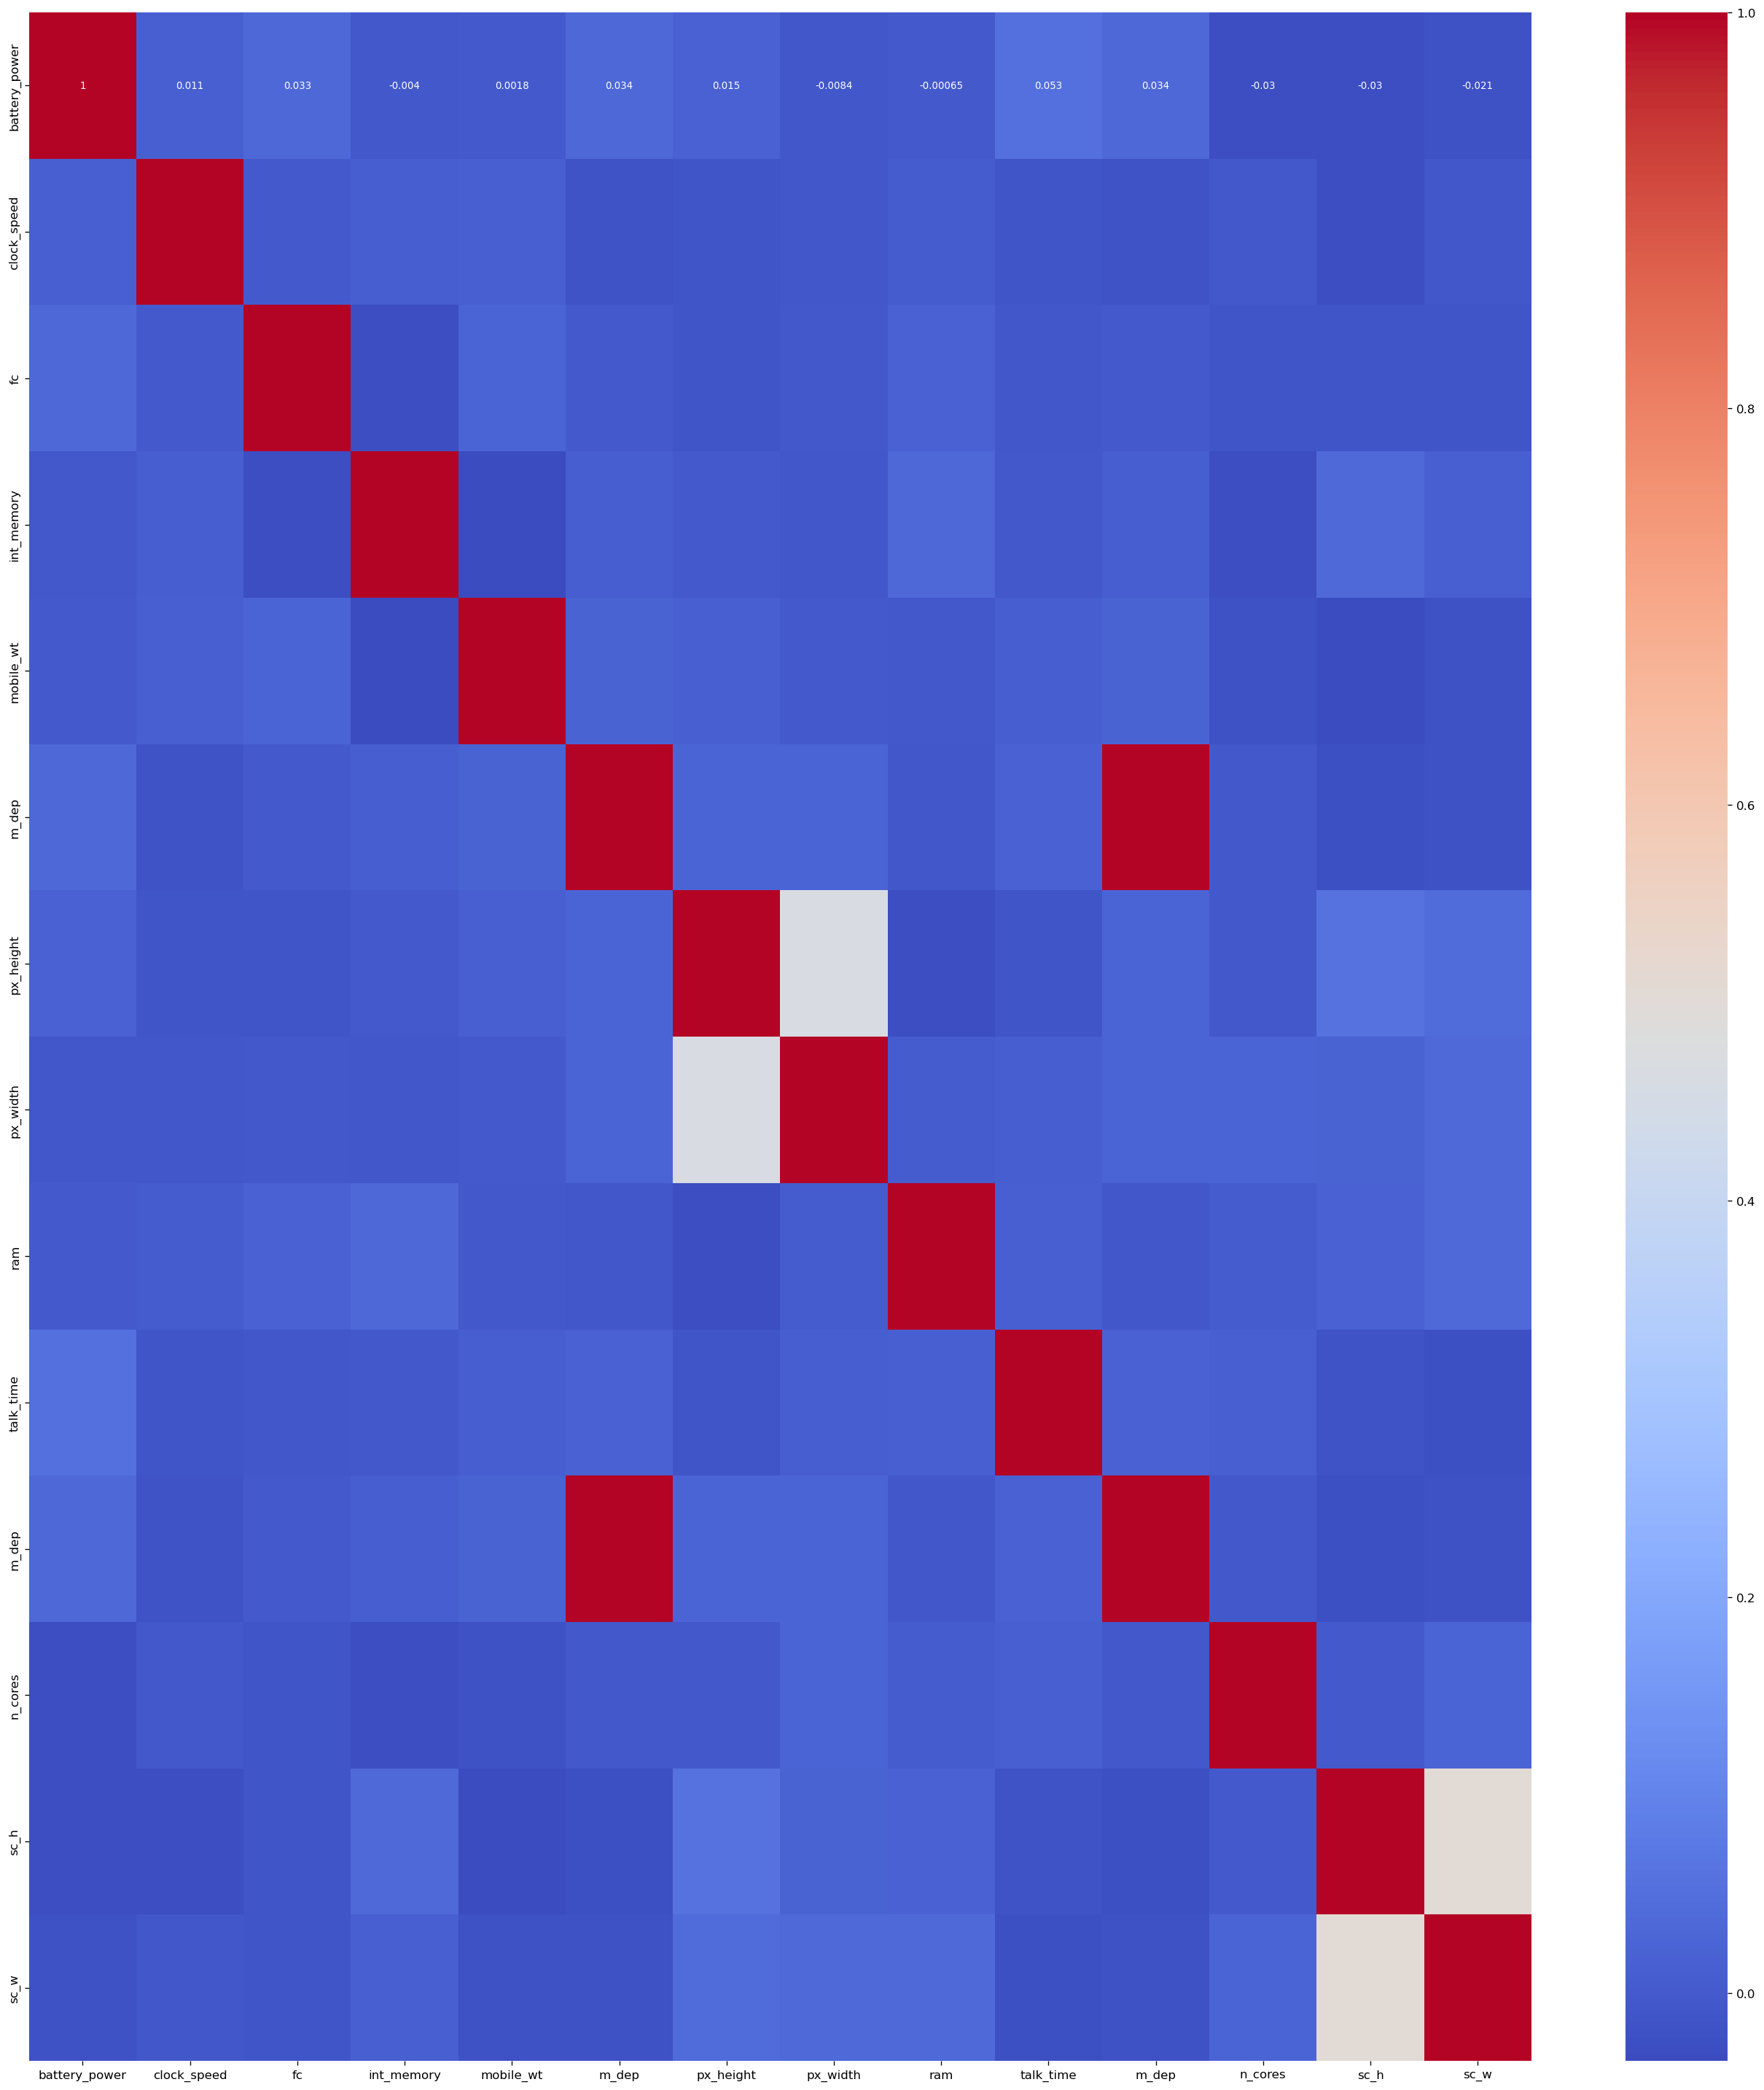

In [24]:
plt.figure(figsize=(22, 24), dpi=120)  # Larger size and increased DPI for clarity
sns.heatmap(data1.corr(), annot=True, annot_kws={"size": 8}, cmap="coolwarm")  # Smaller annotation font size
plt.tight_layout()  # Adjust layout to fit annotations
plt.show()


## Model Selection Process

In [25]:
x = data.drop("price_range",axis=1) # create the independent variable
y = data.price_range  # create the dependent variable

In [26]:
x  # Show the independent variable

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,4.472136,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,30.083218,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,35.538711,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,34.871192,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,34.756294,1212,1411,8,2,15,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,14,34.957117,1890,668,13,4,19,1,1,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,3,30.248967,1965,2032,11,10,16,1,1,1
1997,1911,0,0.9,1,1,1,36,0.7,108,8,3,29.461840,1632,3057,9,1,5,1,1,0
1998,1512,0,0.9,0,4,1,46,0.1,145,5,5,18.330303,670,869,18,10,19,1,1,1


In [27]:
y  # Show the dependent variable

0       1
1       2
2       2
3       2
4       1
       ..
1995    0
1996    2
1997    3
1998    0
1999    3
Name: price_range, Length: 2000, dtype: int64

In [28]:
# use for traning and testing data use library is train_test_split
from sklearn.model_selection import train_test_split # import the train test split model
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=40) # create a train test split

In [29]:
x_train # check the spliting trainig data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
1239,1240,0,1.6,0,0,0,39,0.1,146,2,9,38.871583,1756,3260,13,1,17,0,0,1
426,1190,1,2.2,1,9,0,47,0.3,186,6,10,37.643060,1441,624,9,3,19,1,1,1
1249,504,1,2.8,1,2,0,54,0.4,163,2,10,34.741906,1539,2378,17,11,2,1,0,0
727,1590,0,0.6,1,0,0,7,0.3,122,3,17,38.262253,1595,1201,12,3,18,1,1,1
800,1439,0,0.9,0,12,1,20,0.8,147,1,17,25.019992,932,1790,19,12,15,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016,551,1,2.8,0,0,1,54,0.1,172,7,15,13.000000,1916,1414,6,1,19,1,0,1
165,517,0,1.4,1,3,1,33,0.8,183,4,8,25.690465,974,3704,17,16,11,1,0,1
7,1954,0,0.5,1,0,0,24,0.8,187,4,0,22.627417,1149,700,16,3,5,1,1,1
219,1551,0,1.1,0,4,0,51,0.1,88,5,6,41.689327,1995,3844,11,8,4,0,1,0


In [30]:
x_test  # check the spliting testing data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
423,1681,1,2.5,0,2,0,11,0.4,158,2,13,13.964240,1205,1122,12,6,16,0,1,1
1495,1472,0,3.0,0,4,1,20,0.3,169,2,6,21.047565,892,797,6,1,11,1,1,0
1618,502,0,0.8,0,7,0,52,1.0,82,6,8,16.763055,1159,2666,5,4,20,1,1,0
1099,1697,0,0.5,0,0,1,60,0.1,90,4,0,9.380832,1046,441,15,1,11,1,1,0
1307,831,0,1.7,1,7,1,26,0.7,177,5,11,22.605309,621,1704,6,5,20,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,1303,0,1.0,1,0,1,15,0.1,138,3,10,15.132746,1604,2574,12,4,14,1,1,1
1379,771,0,2.9,0,2,0,62,0.7,106,1,8,41.340053,1781,1628,9,3,6,0,1,0
837,787,1,0.5,0,15,0,11,0.6,93,1,16,28.390139,1423,2934,8,6,14,1,0,1
877,1444,0,0.6,0,2,0,48,0.5,82,5,17,33.045423,1554,2540,17,2,15,1,1,1


## Desicion Tree Algorithm

In [31]:
from sklearn.tree import DecisionTreeRegressor # import the DT model
DT = DecisionTreeRegressor(random_state = 100,max_depth= 10) # call the DT model
DT.fit(x_train,y_train) # train the model

DecisionTreeRegressor(max_depth=10, random_state=100)

In [32]:
y_dt = DT.predict(x_test) # predict the test data


In [33]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error  # import the linear regression metrics

In [34]:
r2_1 = r2_score(y_test,y_dt)  # check the model performace
r2_1

0.8803071127715415

In [35]:
mean_absolute_error(y_test,y_dt) # check the mean absolute error

0.15952954675846243

In [36]:
mse1 = mean_squared_error(y_test,y_dt)  # check the mean squared error value
mse1

0.1542572007378566

In [37]:
mb1 = mean_absolute_error(y_test,y_dt) # check the absolute error value
mb1

0.15952954675846243

In [38]:
y_trdt = DT.predict(x_train)  # predict the train data

In [39]:
r2_score(y_train,y_trdt)  # check the model performace

0.9961127835105552

In [40]:
error2 = y_test - y_dt  # check the error value
error2 

423    -1.0
1495    0.0
1618    1.0
1099    0.0
1307   -1.0
       ... 
739     0.0
1379   -1.0
837     0.0
877     0.0
828     0.0
Name: price_range, Length: 400, dtype: float64

<Axes: xlabel='price_range', ylabel='Count'>

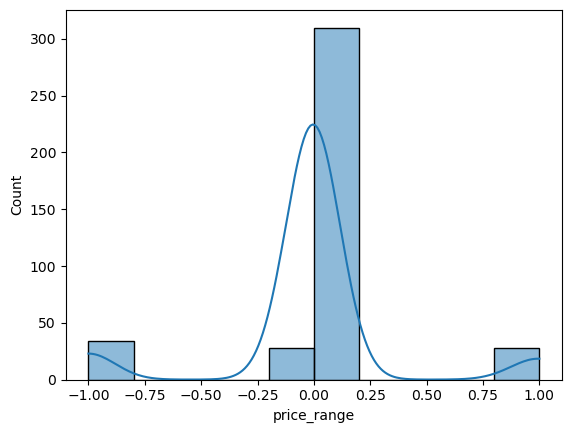

In [41]:
sns.histplot(x = error2,kde=True)  # show the error value in plot

## KNN:- K Nearest Neigbour


In [42]:
from sklearn.neighbors import KNeighborsRegressor # import the KNN model
KNN = KNeighborsRegressor() # call the KNN model
KNN.fit(x_train,y_train)  # train the model

KNeighborsRegressor()

In [43]:
y_knn = KNN.predict(x_test) # predict the test data

In [44]:
r2_2 = r2_score(y_test,y_knn)  # check the model performace
r2_2

0.9431242846889488

In [45]:
mse2 = mean_squared_error(y_test,y_knn)  # check the mean squared error value
mse2

0.0733

In [46]:
mb2 = mean_absolute_error(y_test,y_knn) # check the absolute error value
mb2

0.1425

In [47]:
y_trknn = KNN.predict(x_train) # predict the traning data

In [48]:
r2_score(y_train,y_trknn) # check the trainig data performance

0.9515494278250547

In [49]:
error9 = y_test - y_knn # check the error value
error9

423    -0.8
1495    0.0
1618    0.6
1099    0.0
1307   -0.4
       ... 
739     0.0
1379   -0.2
837     0.0
877     1.0
828     0.0
Name: price_range, Length: 400, dtype: float64

<Axes: xlabel='price_range', ylabel='Count'>

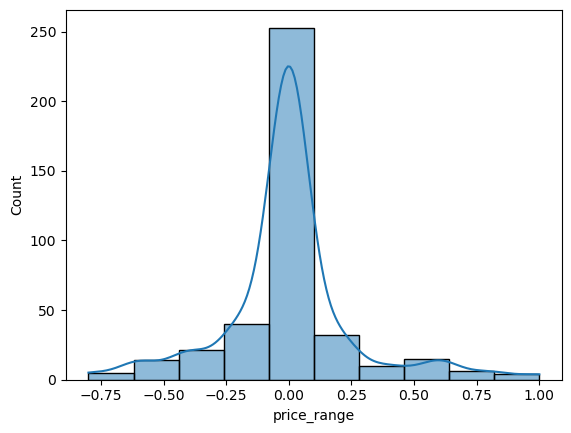

In [50]:
sns.histplot(x = error9,kde=True) # error value show in plot

## Bagging Algorithm

In [51]:
from sklearn.ensemble import BaggingRegressor # import the BG model
BG = BaggingRegressor() # call BG model
BG.fit(x_train,y_train)  # train the model

BaggingRegressor()

In [52]:
y_bg = BG.predict(x_test) # predict the test data

In [53]:
r2_3 = r2_score(y_test,y_bg)  # check the model performace
r2_3

0.9407576962619542

In [54]:
mse3 = mean_squared_error(y_test,y_bg)  # check the mean squared error value
mse3



0.07635

In [55]:
mb3 = mean_absolute_error(y_test,y_bg) # check the absolute error value
mb3

0.163

In [56]:
y_trbg = BG.predict(x_train) # predict the train data

In [57]:
r2_score(y_train,y_trbg) # check the model performance

0.9874891468853294

In [58]:
error8 = y_test - y_bg # check the error value
error8

423    -1.0
1495   -0.1
1618    0.4
1099    0.0
1307   -0.9
       ... 
739     0.0
1379    0.0
837    -0.3
877     0.9
828     0.0
Name: price_range, Length: 400, dtype: float64

<Axes: xlabel='price_range', ylabel='Count'>

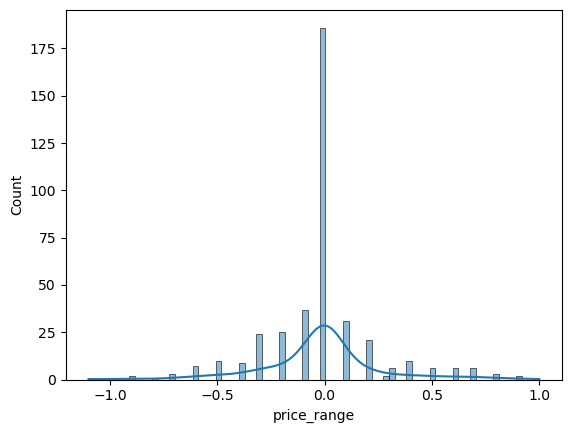

In [59]:
sns.histplot(x = error8,kde=True) # error value show in plot

## Xtrame Gradiant Boosting

In [60]:
!pip install xgboost


In [61]:
from xgboost import XGBRegressor # Import the XGB model
XGB = XGBRegressor() # call XGB model
XGB.fit(x_train,y_train)  # train the model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [62]:
y_xgb = XGB.predict(x_test)  # predict the test data

In [63]:
r2_4 = r2_score(y_test,y_xgb)  # check the model performace
r2_4

0.9427197389056337

In [64]:
mse4 = mean_squared_error(y_test,y_xgb)  # check the mean squared error value
mse4

0.07382136849189205

In [65]:
mb4 = mean_absolute_error(y_test,y_xgb) # check the absolute error value
mb4

0.1769624371099053

In [66]:
y_trxgb = XGB.predict(x_train) # predict the train the data

In [67]:
r2_score(y_train,y_trxgb) # check the model Performance


0.9999290405944876

In [68]:
error4 = y_test - y_xgb # check the error value 
error4

423    -0.820494
1495   -0.001553
1618    0.702879
1099   -0.070593
1307   -0.820419
          ...   
739     0.070944
1379   -0.387262
837    -0.073251
877     0.315367
828    -0.007379
Name: price_range, Length: 400, dtype: float64

<Axes: xlabel='price_range', ylabel='Count'>

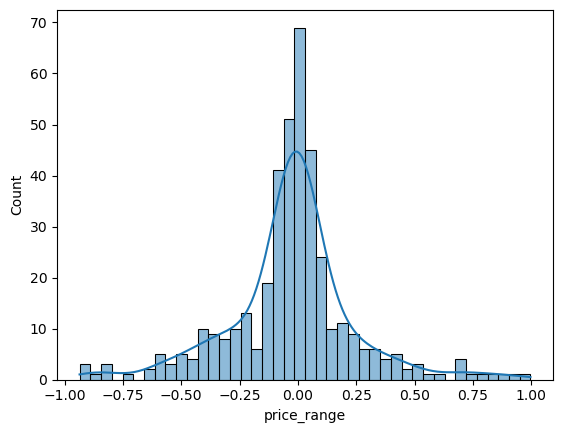

In [69]:
sns.histplot(x = error4,kde=True) # error value based on plot the graph

## Ada Boosting Algorithm

In [70]:
from sklearn.ensemble import AdaBoostRegressor # import the ADA model
ADA = AdaBoostRegressor() # call the ADA model
ADA.fit(x_train,y_train)  # train the model


AdaBoostRegressor()

In [71]:
y_ada = ADA.predict(x_test)  # predict the test data

In [72]:
r2_5 = r2_score(y_test,y_ada)  # check the model performace
r2_5

0.8767291521868166

In [73]:
mse5 = mean_squared_error(y_test,y_ada)  # check the mean squared error value
mse5


0.15886838689043553

In [74]:
mb5 = mean_absolute_error(y_test,y_ada) # check the absolute error value
mb5


0.3766900997719227

In [75]:
y_trada = ADA.predict(x_train)  # predict the training data


In [76]:
r2_score(y_train,y_trada)   # check the trainig data performance

0.8747018324910277

In [77]:
error7 = y_test - y_ada # check the error value between actual data and predicted data
error7


423    -0.492308
1495   -0.431193
1618    0.487730
1099   -0.443182
1307   -0.456897
          ...   
739     0.076433
1379   -0.378788
837    -0.580569
877     0.382166
828     0.228758
Name: price_range, Length: 400, dtype: float64

<Axes: xlabel='price_range', ylabel='Count'>

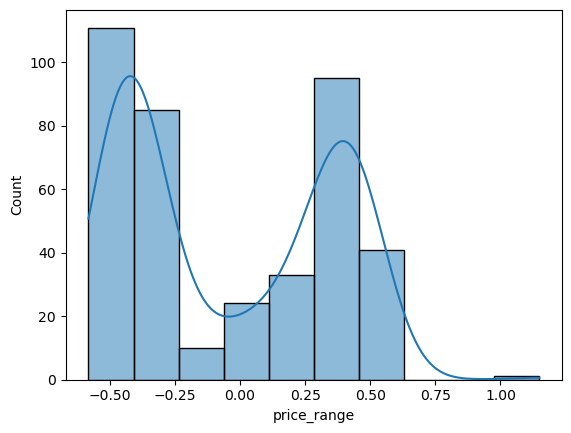

In [78]:
sns.histplot(x=error7, kde=True) # show the error value histogram plot

## Gradiant Boosting Algorithm

In [79]:
from sklearn.ensemble import GradientBoostingRegressor # import the gb model
GB = GradientBoostingRegressor() # call GB model
BG.fit(x_train,y_train)  # train the model

BaggingRegressor()

In [80]:
y_bg = BG.predict(x_test)  # predict the test data

In [81]:
r2_6= r2_score(y_test,y_bg)  # check the model performace
r2_6

0.9449477216736824

In [82]:
mse6 = mean_squared_error(y_test,y_bg)  # check the mean squared error value
mse6


0.07095000000000001

In [83]:
mb6= mean_absolute_error(y_test,y_bg) # check the absolute error value
mb6

0.16450000000000004

In [84]:
y_trbg = BG.predict(x_train) # predict the train the data


In [85]:
r2_score(y_train,y_trbg) # check the model Performance


0.9865767921658469

In [86]:
error3 = y_test - y_bg # check the error value
error3

423    -0.9
1495    0.0
1618    0.4
1099    0.0
1307   -0.6
       ... 
739     0.0
1379   -0.1
837    -0.1
877     0.5
828     0.0
Name: price_range, Length: 400, dtype: float64

<Axes: xlabel='price_range', ylabel='Count'>

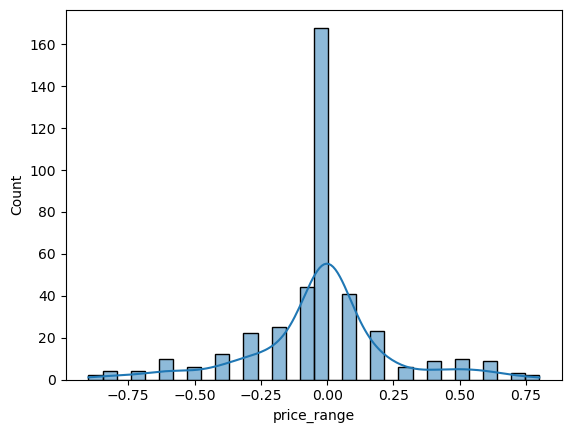

In [87]:
sns.histplot(x = error3,kde=True) # error value based on plot the graph


## RandomForest Algorithm

In [88]:
from sklearn.ensemble import RandomForestRegressor # import the RM model
RM = RandomForestRegressor() # call RM model
RM.fit(x_train,y_train)  # train the model

RandomForestRegressor()

In [89]:
y_rm = RM.predict(x_test)
# predict the test data

In [90]:
r2_7 = r2_score(y_test,y_rm)  # check the model performace
r2_7

0.9511128785086613

In [91]:
mse7 = mean_squared_error(y_test,y_rm)  # check the mean squared error value
mse7

0.06300449999999999

In [92]:
mb7 = mean_absolute_error(y_test,y_rm) # check the absolute error value
mb7

0.15679999999999997

In [93]:
y_trrm = RM.predict(x_train) # predict the train data

In [94]:
r2_score(y_train,y_trrm)  # check the trainig data performance

0.9911185040406981

In [95]:
error5 = y_test - y_rm # check the error value
error5

423    -0.85
1495   -0.01
1618    0.26
1099    0.00
1307   -0.77
        ... 
739    -0.01
1379   -0.39
837    -0.16
877     0.52
828     0.00
Name: price_range, Length: 400, dtype: float64

<Axes: xlabel='price_range', ylabel='Count'>

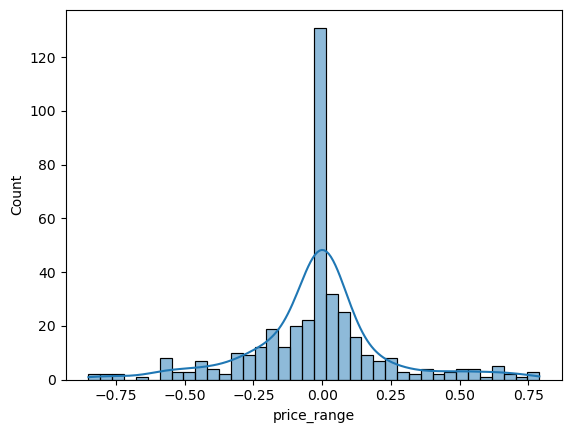

In [96]:
sns.histplot(x = error5,kde=True) # error value show in plot

## Model Comparison Report

In [97]:
# check the all algorithm model perforamnce in table form
# check the Model name, r2_score, mean_squer_error, mean_absolute_error
score = pd.DataFrame({"Model":["DecisionTreeRegressor","KNN","Bagging","XGBRegressor","AdaBoosting","GradiantBoosting","RandomForestRegressor"],
                     "r2_score":[r2_1*100,r2_2*100,r2_3*100,r2_4*100,r2_5*100,r2_6*100,r2_7*100],
                     "MSE":[mse1,mse2,mse3,mse4,mse5,mse6,mse7],
                     "MAE":[mb1,mb2,mb3,mb4,mb5,mb6,mb7]})
score

,Model,r2_score,MSE,MAE
0,DecisionTreeRegressor,88.030711,0.154257,0.159530
1,KNN,94.312428,0.073300,0.142500
2,Bagging,94.075770,0.076350,0.163000
3,XGBRegressor,94.271974,0.073821,0.176962
4,AdaBoosting,87.672915,0.158868,0.376690
5,GradiantBoosting,94.494772,0.070950,0.164500
6,RandomForestRegressor,95.111288,0.063004,0.156800


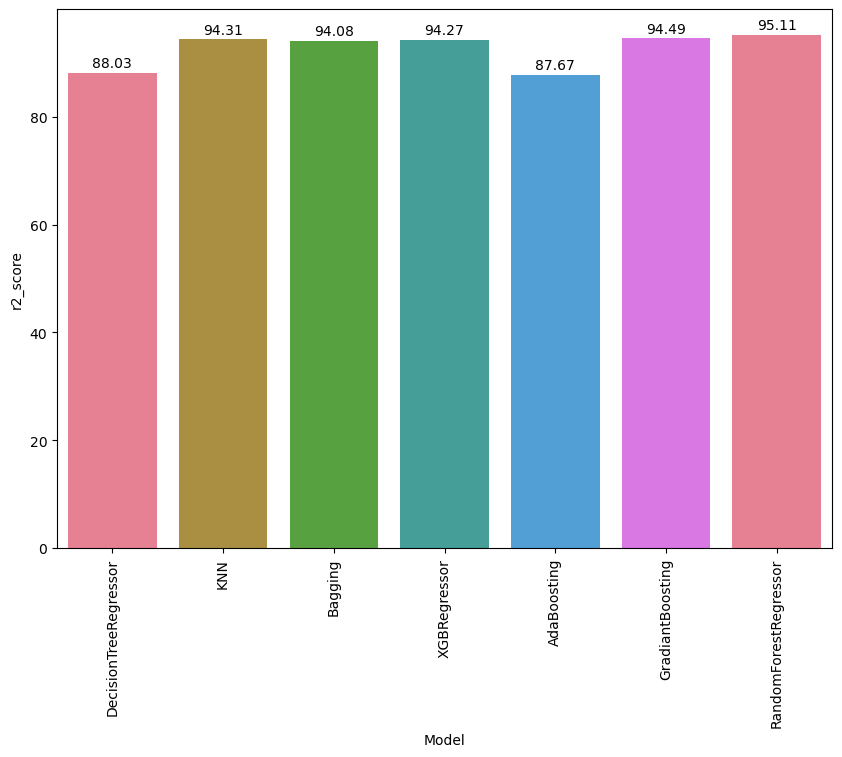

In [98]:
# use for All model performance show in barplot graph
palette = sns.color_palette("husl") # define the color for barplot 
plt.figure(figsize=(10, 7)) # define the plot size
plt.xticks(rotation = 90) # show the x axis value rotation
a = sns.barplot(x=score.Model, y=score.r2_score, data=score, palette=palette) # create the barplot

for index, value in enumerate(score['r2_score']): # show indivisual bar values show
    a.text(index, value + 1, f'{value:.2f}', ha='center')



______Final_Conclusion_of_Model_Report______



* I have used total 10 Algorithm like DecisionTreeRegressor, KNN, Bagging, GradientBoosting, XGBRegressor, AdaBoosting, Randomforest.
* Best Algorithm is RandomForest beacause its r2_score is 95.1 and mean squared error is 0.06.
* Most of algorithm provide the accuracy_score is 94.0 plus.
* Most of algorithm error valuse show the Normal Distribution.
* Most of the algorithm inside not use the hyperparameter model beacuse most of model generalized model.

____Report_On_Challenges_Faced___



* The analysis of the bike rental dataset reveals that it contains 2000 entries and 21 columns, with 20 input features and 1 target variable.
* Among the columns, there are 2 float data types, and 19 are int data type.
* The dataset presents challenges due to some presence of outliers across in some columns and does not exhibit a normal distribution for all features.

## Model Save

In [99]:
import pickle # use for save the model
with open("CellPhonePrice.pkl","wb") as f:  # define the file save
    pickle.dump(RM,f) # call the rm model

In [100]:
with open("CellPhonePrice.pkl","rb") as f: # load the model file
    file = pickle.load(f) # call the file

In [101]:
x.head()  # showning the top data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,4.472136,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,30.083218,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,35.538711,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,34.871192,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,34.756294,1212,1411,8,2,15,1,1,0


In [102]:
y.head() # showning the top data

0    1
1    2
2    2
3    2
4    1
Name: price_range, dtype: int64

In [103]:
file.predict([[842,	0	,2.2,	0,	1,	0,	7,	0.6,	188,	2,	2,	4.472136	,756	,2549	,9,	7,	19,	0,	0,	1]])

array([1.3])

                                                        ! Thank you !